In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

# Load NAV history
nav_history = pd.read_csv("../data/raw/nav_history.csv")

# Load benchmark data
benchmark_indices = pd.read_csv("../data/raw/benchmark_indices.csv")

print("NAV History Shape:", nav_history.shape)
print("Benchmark Shape:", benchmark_indices.shape)

print("\nNAV History Columns:")
print(nav_history.columns.tolist())

print("\nBenchmark Columns:")
print(benchmark_indices.columns.tolist())

print("\nFirst 5 rows of NAV History:")
display(nav_history.head())

print("\nFirst 5 rows of Benchmark Data:")
display(benchmark_indices.head())

NAV History Shape: (46000, 3)
Benchmark Shape: (8050, 3)

NAV History Columns:
['amfi_code', 'date', 'nav']

Benchmark Columns:
['date', 'index_name', 'close_value']

First 5 rows of NAV History:


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692



First 5 rows of Benchmark Data:


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [4]:
# Make a copy so that the original dataframe remains unchanged
nav = nav_history.copy()

nav["date"] = pd.to_datetime(nav["date"])

nav["nav"] = pd.to_numeric(nav["nav"], errors="coerce")

nav = nav.sort_values(
    by=["amfi_code", "date"]
).reset_index(drop=True)

print("=" * 70)
print("NAV DATA VALIDATION")
print("=" * 70)

print("\nTotal rows:", len(nav))

print("Number of unique schemes:", nav["amfi_code"].nunique())

print("Date range:")
print("Start:", nav["date"].min())
print("End:", nav["date"].max())

print("\nMissing values:")
print(nav.isnull().sum())

duplicate_records = nav.duplicated(
    subset=["amfi_code", "date"]
).sum()

print("\nDuplicate scheme-date records:", duplicate_records)

negative_nav = (nav["nav"] <= 0).sum()

print("NAV values <= 0:", negative_nav)

scheme_counts = nav.groupby("amfi_code").size()

print("\nObservations per scheme:")
print(scheme_counts.describe())

print("\nMinimum observations for one scheme:",
      scheme_counts.min())

print("Maximum observations for one scheme:",
      scheme_counts.max())

print("\nFirst 10 cleaned NAV records:")
display(nav.head(10))

NAV DATA VALIDATION

Total rows: 46000
Number of unique schemes: 40
Date range:
Start: 2022-01-03 00:00:00
End: 2026-05-29 00:00:00

Missing values:
amfi_code    0
date         0
nav          0
dtype: int64

Duplicate scheme-date records: 0
NAV values <= 0: 0

Observations per scheme:
count      40.0
mean     1150.0
std         0.0
min      1150.0
25%      1150.0
50%      1150.0
75%      1150.0
max      1150.0
dtype: float64

Minimum observations for one scheme: 1150
Maximum observations for one scheme: 1150

First 10 cleaned NAV records:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
5,100016,2022-01-10,510.7136
6,100016,2022-01-11,513.5542
7,100016,2022-01-12,512.3195
8,100016,2022-01-13,510.2445
9,100016,2022-01-14,514.3636


DAILY RETURN CALCULATION

First 15 records with daily returns:


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073



Missing daily returns: 40

Daily Return Summary Statistics:


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


Largest daily returns:


,amfi_code,date,daily_return
24745,119598,2024-04-15,0.064713
13226,118634,2024-03-19,0.059304
5207,101207,2024-05-01,0.054851
25566,119599,2023-01-10,0.053320
25832,119599,2024-01-17,0.051811
24155,119598,2022-01-10,0.051113
24371,119598,2022-11-08,0.049051
45082,149324,2022-11-23,0.048490
24356,119598,2022-10-18,0.048454
25091,119598,2025-08-12,0.047123



Smallest daily returns:


,amfi_code,date,daily_return
12774,118634,2022-06-24,-0.058102
4917,101207,2023-03-22,-0.051847
12952,118634,2023-03-01,-0.050335
45312,149324,2023-10-11,-0.048870
5560,101207,2025-09-08,-0.048634
19804,119095,2022-12-23,-0.048367
13333,118634,2024-08-15,-0.048305
20307,119095,2024-11-27,-0.046524
26048,119599,2024-11-14,-0.045429
38520,125498,2024-03-11,-0.045218


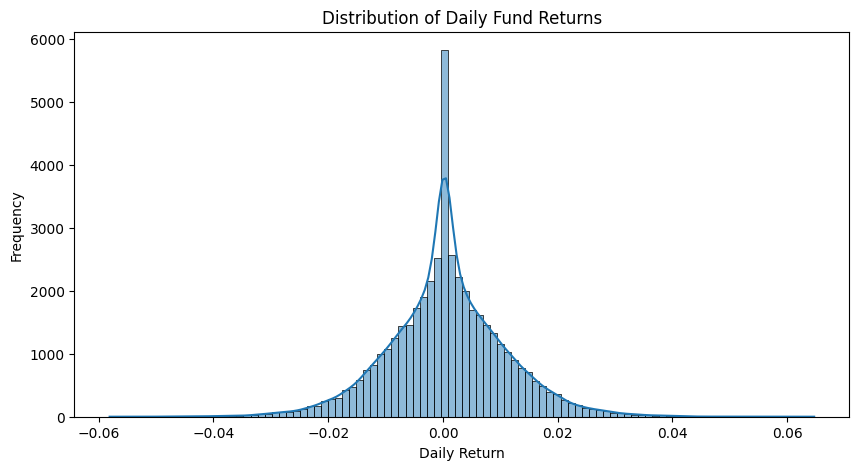

In [6]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print("=" * 70)
print("DAILY RETURN CALCULATION")
print("=" * 70)
print("\nFirst 15 records with daily returns:")

display(
    nav[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(15)
)
missing_returns = nav["daily_return"].isna().sum()

print("\nMissing daily returns:", missing_returns)
print("\nDaily Return Summary Statistics:")

display(
    nav["daily_return"].describe()
)
print("\nLargest daily returns:")

display(
    nav.nlargest(10, "daily_return")[
        ["amfi_code", "date", "daily_return"]
    ]
)

print("\nSmallest daily returns:")

display(
    nav.nsmallest(10, "daily_return")[
        ["amfi_code", "date", "daily_return"]
    ]
)
plt.figure(figsize=(10, 5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [8]:

def calculate_cagr(fund_data, years):
    
    
    fund_data = fund_data.sort_values("date")
    
    start_date = fund_data["date"].min()
    end_date = fund_data["date"].max()
    
    target_start_date = end_date - pd.DateOffset(years=years)
    
    if start_date > target_start_date:
        return np.nan
    
    start_data = fund_data[
        fund_data["date"] >= target_start_date
    ].sort_values("date")
    
    if start_data.empty:
        return np.nan
    
    start_row = start_data.iloc[0]
    
    nav_start = start_row["nav"]
    nav_end = fund_data.iloc[-1]["nav"]
    
    actual_start_date = start_row["date"]
    actual_end_date = fund_data.iloc[-1]["date"]
    
    actual_years = (
        actual_end_date - actual_start_date
    ).days / 365.25
    
    if nav_start <= 0 or nav_end <= 0 or actual_years <= 0:
        return np.nan
    
    
    cagr = (
        (nav_end / nav_start) ** (1 / actual_years)
    ) - 1
    
    return cagr


cagr_results = []

for amfi_code, fund_data in nav.groupby("amfi_code"):
    
    result = {
        "amfi_code": amfi_code,
        "cagr_1y": calculate_cagr(fund_data, 1),
        "cagr_3y": calculate_cagr(fund_data, 3),
        "cagr_5y": calculate_cagr(fund_data, 5)
    }
    
    cagr_results.append(result)


cagr_table = pd.DataFrame(cagr_results)

cagr_table["cagr_1y_pct"] = cagr_table["cagr_1y"] * 100
cagr_table["cagr_3y_pct"] = cagr_table["cagr_3y"] * 100
cagr_table["cagr_5y_pct"] = cagr_table["cagr_5y"] * 100

print("=" * 70)
print("CAGR COMPARISON — ALL FUNDS")
print("=" * 70)

display(
    cagr_table[
        [
            "amfi_code",
            "cagr_1y_pct",
            "cagr_3y_pct",
            "cagr_5y_pct"
        ]
    ].sort_values(
        "cagr_3y_pct",
        ascending=False
    )
)

print("\nCAGR Availability:")

print(
    "1-Year CAGR available:",
    cagr_table["cagr_1y"].notna().sum(),
    "of",
    len(cagr_table)
)

print(
    "3-Year CAGR available:",
    cagr_table["cagr_3y"].notna().sum(),
    "of",
    len(cagr_table)
)

print(
    "5-Year CAGR available:",
    cagr_table["cagr_5y"].notna().sum(),
    "of",
    len(cagr_table)
)

CAGR COMPARISON — ALL FUNDS


,amfi_code,cagr_1y_pct,cagr_3y_pct,cagr_5y_pct
16,119094,22.277897,35.102528,NaN
34,148567,20.375957,33.991970,NaN
24,120504,13.073788,32.478927,NaN
2,100033,53.277195,32.433971,NaN
25,120505,29.627681,31.769243,NaN
19,119551,60.489297,30.448613,NaN
30,120843,26.677584,29.575111,NaN
36,148569,39.783803,29.171358,NaN
3,101206,47.963794,28.960211,NaN
39,149324,65.195466,26.993503,NaN



CAGR Availability:
1-Year CAGR available: 40 of 40
3-Year CAGR available: 40 of 40
5-Year CAGR available: 0 of 40


In [9]:

RISK_FREE_ANNUAL = 0.065


RISK_FREE_DAILY = (1 + RISK_FREE_ANNUAL) ** (1 / 252) - 1

print("=" * 70)
print("SHARPE RATIO CALCULATION")
print("=" * 70)

print("\nAnnual Risk-Free Rate:", RISK_FREE_ANNUAL * 100, "%")
print("Daily Risk-Free Rate:", RISK_FREE_DAILY)



sharpe_results = []

for amfi_code, fund_data in nav.groupby("amfi_code"):

    
    returns = fund_data["daily_return"].dropna()


    mean_return = returns.mean()


    std_return = returns.std()


    if std_return == 0 or pd.isna(std_return):
        sharpe = np.nan
    else:
        sharpe = (
            (mean_return - RISK_FREE_DAILY)
            / std_return
        ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "sharpe_ratio": sharpe
    })


sharpe_table = pd.DataFrame(sharpe_results)


sharpe_table = sharpe_table.sort_values(
    "sharpe_ratio",
    ascending=False
).reset_index(drop=True)

sharpe_table["sharpe_rank"] = (
    sharpe_table.index + 1
)

print("\n" + "=" * 70)
print("FUND SHARPE RANKING")
print("=" * 70)

display(sharpe_table)

print("\nSharpe Ratio Statistics:")

display(
    sharpe_table["sharpe_ratio"].describe()
)

SHARPE RATIO CALCULATION

Annual Risk-Free Rate: 6.5 %
Daily Risk-Free Rate: 0.00024993122427763304

FUND SHARPE RANKING


,amfi_code,sharpe_ratio,sharpe_rank
0,148567,1.462504,1
1,120843,1.319442,2
2,148569,1.246344,3
3,119551,1.222947,4
4,120505,1.190559,5
5,149323,1.143490,6
6,100033,1.104352,7
7,118632,1.095918,8
8,101206,1.041061,9
9,120504,1.040569,10



Sharpe Ratio Statistics:


count    40.000000
mean      0.581513
std       0.542977
min      -0.515438
25%       0.129849
50%       0.671260
75%       1.016612
max       1.462504
Name: sharpe_ratio, dtype: float64

In [10]:

print("=" * 70)
print("SORTINO RATIO CALCULATION")
print("=" * 70)

sortino_results = []

for amfi_code, fund_data in nav.groupby("amfi_code"):

    
    returns = fund_data["daily_return"].dropna()

    
    mean_return = returns.mean()

    negative_returns = returns[returns < 0]

    if len(negative_returns) == 0:
        sortino = np.nan

    else:
        downside_deviation = negative_returns.std()

        if downside_deviation == 0 or pd.isna(downside_deviation):
            sortino = np.nan

        else:
            sortino = (
                (mean_return - RISK_FREE_DAILY)
                / downside_deviation
            ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": amfi_code,
        "sortino_ratio": sortino
    })


sortino_table = pd.DataFrame(sortino_results)


sortino_table = sortino_table.sort_values(
    "sortino_ratio",
    ascending=False
).reset_index(drop=True)

sortino_table["sortino_rank"] = (
    sortino_table.index + 1
)


print("\n" + "=" * 70)
print("FUND SORTINO RANKING")
print("=" * 70)

display(sortino_table)

print("\nSortino Ratio Statistics:")

display(
    sortino_table["sortino_ratio"].describe()
)

SORTINO RATIO CALCULATION

FUND SORTINO RANKING


,amfi_code,sortino_ratio,sortino_rank
0,148567,2.409056,1
1,120843,2.387295,2
2,148569,2.166757,3
3,119551,2.166272,4
4,120505,2.047336,5
5,120507,1.918995,6
6,149323,1.893929,7
7,118632,1.874521,8
8,100033,1.846950,9
9,120504,1.829993,10



Sortino Ratio Statistics:


count    40.000000
mean      1.010714
std       0.946934
min      -0.859988
25%       0.220069
50%       1.172418
75%       1.825365
max       2.409056
Name: sortino_ratio, dtype: float64

In [11]:

benchmark = benchmark_indices.copy()


benchmark["date"] = pd.to_datetime(benchmark["date"])


benchmark["close_value"] = pd.to_numeric(
    benchmark["close_value"],
    errors="coerce"
)


nifty100 = benchmark[
    benchmark["index_name"].str.upper() == "NIFTY100"
].copy()


nifty100 = nifty100.sort_values("date")
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print("=" * 70)
print("NIFTY 100 BENCHMARK PREPARATION")
print("=" * 70)

print("\nNifty 100 rows:", len(nifty100))

print(
    "Date range:",
    nifty100["date"].min(),
    "to",
    nifty100["date"].max()
)

print(
    "\nMissing benchmark returns:",
    nifty100["benchmark_return"].isna().sum()
)

print("\nFirst 10 Nifty 100 returns:")

display(
    nifty100[
        ["date", "close_value", "benchmark_return"]
    ].head(10)
)

NIFTY 100 BENCHMARK PREPARATION

Nifty 100 rows: 1150
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00

Missing benchmark returns: 1

First 10 Nifty 100 returns:


,date,close_value,benchmark_return
1150,2022-01-03,17778.24,NaN
1151,2022-01-04,17537.52,-0.013540
1152,2022-01-05,17607.73,0.004003
1153,2022-01-06,17556.05,-0.002935
1154,2022-01-07,17664.02,0.006150
1155,2022-01-10,17516.51,-0.008351
1156,2022-01-11,17603.08,0.004942
1157,2022-01-12,17763.76,0.009128
1158,2022-01-13,17830.30,0.003746
1159,2022-01-14,17578.93,-0.014098


In [12]:
print("=" * 70)
print("MAXIMUM DRAWDOWN CALCULATION")
print("=" * 70)

drawdown_results = []

for amfi_code, fund_data in nav.groupby("amfi_code"):

    fund_data = fund_data.sort_values("date").copy()

    # Calculate running maximum NAV
    fund_data["running_max"] = fund_data["nav"].cummax()

    # Calculate drawdown
    fund_data["drawdown"] = (
        fund_data["nav"] / fund_data["running_max"]
    ) - 1

    # Find the worst drawdown
    trough_idx = fund_data["drawdown"].idxmin()

    trough_row = fund_data.loc[trough_idx]

    max_drawdown = trough_row["drawdown"]

    # Find the peak NAV before the trough
    peak_nav = trough_row["running_max"]

    peak_data = fund_data[
        (fund_data["date"] <= trough_row["date"]) &
        (fund_data["nav"] == peak_nav)
    ]

    peak_row = peak_data.iloc[-1]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown": max_drawdown,
        "peak_date": peak_row["date"],
        "trough_date": trough_row["date"],
        "peak_nav": peak_row["nav"],
        "trough_nav": trough_row["nav"]
    })


drawdown_table = pd.DataFrame(drawdown_results)

drawdown_table = drawdown_table.sort_values(
    "max_drawdown",
    ascending=False
).reset_index(drop=True)

print("\nMaximum Drawdown Ranking:")
display(drawdown_table)

print("\nMaximum Drawdown Statistics:")
display(drawdown_table["max_drawdown"].describe())

print("\nWorst 10 Drawdowns:")
display(
    drawdown_table[
        [
            "amfi_code",
            "max_drawdown",
            "peak_date",
            "trough_date",
            "peak_nav",
            "trough_nav"
        ]
    ].tail(10)
)

MAXIMUM DRAWDOWN CALCULATION

Maximum Drawdown Ranking:


,amfi_code,max_drawdown,peak_date,trough_date,peak_nav,trough_nav
0,120507,-0.000977,2025-10-16,2025-10-20,372.0401,371.6765
1,120844,-0.001163,2024-04-12,2024-04-30,3738.8231,3734.4751
2,101208,-0.001622,2023-09-05,2023-09-12,346.9958,346.4328
3,100025,-0.043083,2023-05-23,2023-07-28,28.7494,27.5108
4,119120,-0.043287,2024-09-16,2025-04-01,52.5004,50.2278
5,118636,-0.083164,2023-02-09,2024-02-09,34.1748,31.3327
6,102885,-0.108599,2022-02-03,2022-03-29,93.7848,83.5999
7,148567,-0.112657,2023-07-11,2023-10-20,101.8496,90.3755
8,101206,-0.112916,2023-04-24,2023-07-05,370.0026,328.2234
9,118635,-0.116506,2022-01-03,2022-06-09,170.3428,150.4968



Maximum Drawdown Statistics:


count    40.000000
mean     -0.178729
std       0.112686
min      -0.525742
25%      -0.215927
50%      -0.163070
75%      -0.117653
max      -0.000977
Name: max_drawdown, dtype: float64


Worst 10 Drawdowns:


,amfi_code,max_drawdown,peak_date,trough_date,peak_nav,trough_nav
30,119093,-0.217514,2022-02-24,2023-05-22,42.2166,33.0339
31,118634,-0.233449,2025-04-09,2026-02-20,126.7224,97.1392
32,120842,-0.240035,2023-11-09,2024-10-17,80.0837,60.8608
33,100016,-0.247344,2022-03-30,2022-09-15,546.3002,411.1759
34,102886,-0.280011,2025-01-07,2026-04-27,169.8164,122.2659
35,119598,-0.287060,2024-08-28,2025-05-14,225.2452,160.5863
36,149324,-0.311719,2024-05-03,2025-01-03,174.4645,120.0806
37,101207,-0.354469,2024-11-21,2026-05-11,80.3517,51.8695
38,119095,-0.516778,2025-05-22,2026-05-11,106.8214,51.6185
39,119599,-0.525742,2023-01-17,2025-10-28,165.7647,78.6152


In [13]:
fund_master = pd.read_csv("../data/raw/fund_master.csv")

print("Fund Master Shape:", fund_master.shape)

display(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "expense_ratio_pct"
        ]
    ].head()
)

Fund Master Shape: (40, 15)


,amfi_code,scheme_name,fund_house,category,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Debt,0.77


In [14]:
scorecard = (
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "expense_ratio_pct"
        ]
    ]
    .merge(
        cagr_table[["amfi_code", "cagr_3y"]],
        on="amfi_code",
        how="left"
    )
    .merge(
        sharpe_table[["amfi_code", "sharpe_ratio"]],
        on="amfi_code",
        how="left"
    )
    .merge(
        alpha_beta_table[["amfi_code", "alpha", "beta"]],
        on="amfi_code",
        how="left"
    )
    .merge(
        drawdown_table[["amfi_code", "max_drawdown"]],
        on="amfi_code",
        how="left"
    )
)

print("=" * 70)
print("FUND SCORECARD — COMBINED METRICS")
print("=" * 70)

print("\nScorecard Shape:", scorecard.shape)

display(scorecard.head())

NameError: name 'alpha_beta_table' is not defined

In [15]:
[name for name in globals() if "alpha" in name.lower() or "beta" in name.lower()]

[]

In [16]:
print("=" * 70)
print("CREATING ALPHA & BETA TABLE")
print("=" * 70)

alpha_beta_results = []

for amfi_code, fund_data in nav.groupby("amfi_code"):

    # Keep only required columns
    fund_returns = fund_data[
        ["date", "daily_return"]
    ].copy()

    benchmark_returns = nifty100[
        ["date", "benchmark_return"]
    ].copy()

    # Match fund returns with Nifty 100 returns by date
    aligned = pd.merge(
        fund_returns,
        benchmark_returns,
        on="date",
        how="inner"
    ).dropna(
        subset=["daily_return", "benchmark_return"]
    )

    # Need enough observations for regression
    if len(aligned) < 30:
        alpha = np.nan
        beta = np.nan
        r_squared = np.nan
    else:
        regression = linregress(
            aligned["benchmark_return"],
            aligned["daily_return"]
        )

        beta = regression.slope

        # Daily alpha -> annual alpha
        alpha = regression.intercept * 252

        r_squared = regression.rvalue ** 2

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha,
        "beta": beta,
        "r_squared": r_squared
    })


alpha_beta_table = pd.DataFrame(alpha_beta_results)

print("\nAlpha & Beta Results:")
display(
    alpha_beta_table.sort_values(
        "alpha",
        ascending=False
    )
)

print("\nNumber of funds:", len(alpha_beta_table))

CREATING ALPHA & BETA TABLE

Alpha & Beta Results:


,amfi_code,alpha,beta,r_squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04
2,100033,0.271954,0.005104,1.206652e-05
34,148567,0.269838,0.023684,4.625437e-04
38,149323,0.265986,-0.002523,3.357978e-06
16,119094,0.260767,-0.066265,1.936879e-03
19,119551,0.232010,-0.031751,8.869789e-04



Number of funds: 40


In [17]:
scorecard = (
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "expense_ratio_pct"
        ]
    ]
    .merge(
        cagr_table[["amfi_code", "cagr_3y"]],
        on="amfi_code",
        how="left"
    )
    .merge(
        sharpe_table[["amfi_code", "sharpe_ratio"]],
        on="amfi_code",
        how="left"
    )
    .merge(
        alpha_beta_table[["amfi_code", "alpha", "beta"]],
        on="amfi_code",
        how="left"
    )
    .merge(
        drawdown_table[["amfi_code", "max_drawdown"]],
        on="amfi_code",
        how="left"
    )
)

print("=" * 70)
print("FUND SCORECARD — COMBINED METRICS")
print("=" * 70)

print("\nScorecard Shape:", scorecard.shape)

display(scorecard.head(10))

print("\nMissing values:")
display(scorecard.isnull().sum())

FUND SCORECARD — COMBINED METRICS

Scorecard Shape: (40, 10)


,amfi_code,scheme_name,fund_house,category,expense_ratio_pct,cagr_3y,sharpe_ratio,alpha,beta,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,1.54,0.304486,1.222947,0.232010,-0.031751,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,0.66,0.162634,0.967752,0.198686,-0.026159,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,1.43,0.266631,0.953332,0.303370,-0.023196,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,0.72,-0.013371,-0.049101,0.048824,0.062002,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Debt,0.77,0.058390,-0.175723,0.056209,-0.006414,-0.043287
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,1.55,0.012924,-0.187650,0.037476,-0.058268,-0.247344
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,Equity,0.92,0.184299,0.789543,0.177298,0.048820,-0.152000
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,1.38,0.324340,1.104352,0.271954,0.005104,-0.162172
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Equity,0.78,0.112425,0.311604,0.119891,0.009054,-0.211173
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,0.56,0.039155,-0.515438,0.042818,0.001158,-0.043083



Missing values:


amfi_code            0
scheme_name          0
fund_house           0
category             0
expense_ratio_pct    0
cagr_3y              0
sharpe_ratio         0
alpha                0
beta                 0
max_drawdown         0
dtype: int64

In [18]:

print("=" * 70)
print("CALCULATING FUND SCORECARD")
print("=" * 70)

n_funds = len(scorecard)
scorecard["cagr_score"] = (
    scorecard["cagr_3y"]
    .rank(ascending=True, method="min", na_option="keep")
)

scorecard["cagr_score"] = (
    (scorecard["cagr_score"] - 1)
    / (scorecard["cagr_score"].max() - 1)
    * 100
)
scorecard["sharpe_score"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=True, method="min", na_option="keep")
)

scorecard["sharpe_score"] = (
    (scorecard["sharpe_score"] - 1)
    / (scorecard["sharpe_score"].max() - 1)
    * 100
)
scorecard["alpha_score"] = (
    scorecard["alpha"]
    .rank(ascending=True, method="min", na_option="keep")
)

scorecard["alpha_score"] = (
    (scorecard["alpha_score"] - 1)
    / (scorecard["alpha_score"].max() - 1)
    * 100
)
scorecard["expense_score"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=False, method="min", na_option="keep")
)

scorecard["expense_score"] = (
    (scorecard["expense_score"] - 1)
    / (scorecard["expense_score"].max() - 1)
    * 100
)
scorecard["drawdown_score"] = (
    scorecard["max_drawdown"]
    .rank(ascending=True, method="min", na_option="keep")
)

scorecard["drawdown_score"] = (
    (scorecard["drawdown_score"] - 1)
    / (scorecard["drawdown_score"].max() - 1)
    * 100
)
scorecard["fund_score"] = (
    scorecard["cagr_score"] * 0.30
    + scorecard["sharpe_score"] * 0.25
    + scorecard["alpha_score"] * 0.20
    + scorecard["expense_score"] * 0.15
    + scorecard["drawdown_score"] * 0.10
)
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

scorecard["rank"] = scorecard.index + 1
final_columns = [
    "rank",
    "amfi_code",
    "scheme_name",
    "category",
    "cagr_3y",
    "sharpe_ratio",
    "alpha",
    "beta",
    "expense_ratio_pct",
    "max_drawdown",
    "fund_score"
]

display(scorecard[final_columns].head(10))

CALCULATING FUND SCORECARD


,rank,amfi_code,scheme_name,category,cagr_3y,sharpe_ratio,alpha,beta,expense_ratio_pct,max_drawdown,fund_score
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.339920,1.462504,0.269838,0.023684,1.46,-0.112657,85.897436
1,2,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.317692,1.190559,0.292636,0.000549,1.36,-0.181885,81.794872
2,3,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.295751,1.319442,0.273305,-0.022830,1.45,-0.129740,81.538462
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.324340,1.104352,0.271954,0.005104,1.38,-0.162172,79.871795
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,0.324789,1.040569,0.211948,0.016232,0.80,-0.125883,79.487179
5,6,119094,Axis Midcap Fund - Regular - Growth,Equity,0.351025,1.008626,0.260767,-0.066265,1.38,-0.209609,76.025641
6,7,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.304486,1.222947,0.232010,-0.031751,1.54,-0.150124,73.974359
7,8,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.291714,1.246344,0.282704,0.018134,1.60,-0.163967,72.820513
8,9,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,0.289602,1.041061,0.213998,0.021086,1.60,-0.112916,67.179487
9,10,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,0.266631,0.953332,0.303370,-0.023196,1.43,-0.287060,66.538462


In [19]:
print("=" * 70)
print("TOP 5 FUNDS FOR BENCHMARK COMPARISON")
print("=" * 70)

top_5_funds = scorecard.head(5).copy()

print("\nTop 5 Funds:")
display(
    top_5_funds[
        [
            "rank",
            "amfi_code",
            "scheme_name",
            "fund_score",
            "cagr_3y",
            "sharpe_ratio",
            "alpha",
            "max_drawdown"
        ]
    ]
)

TOP 5 FUNDS FOR BENCHMARK COMPARISON

Top 5 Funds:


,rank,amfi_code,scheme_name,fund_score,cagr_3y,sharpe_ratio,alpha,max_drawdown
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,85.897436,0.339920,1.462504,0.269838,-0.112657
1,2,120505,ICICI Pru Midcap Fund - Regular - Growth,81.794872,0.317692,1.190559,0.292636,-0.181885
2,3,120843,Kotak Flexicap Fund - Regular - Growth,81.538462,0.295751,1.319442,0.273305,-0.129740
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,79.871795,0.324340,1.104352,0.271954,-0.162172
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,79.487179,0.324789,1.040569,0.211948,-0.125883


In [20]:

top_5_funds = scorecard.head(5).copy()

print("=" * 70)
print("TOP 5 FUNDS FOR BENCHMARK COMPARISON")
print("=" * 70)

display(
    top_5_funds[
        [
            "rank",
            "amfi_code",
            "scheme_name",
            "fund_score"
        ]
    ]
)

TOP 5 FUNDS FOR BENCHMARK COMPARISON


,rank,amfi_code,scheme_name,fund_score
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,85.897436
1,2,120505,ICICI Pru Midcap Fund - Regular - Growth,81.794872
2,3,120843,Kotak Flexicap Fund - Regular - Growth,81.538462
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,79.871795
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,79.487179


In [21]:

benchmark = benchmark_indices.copy()

benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark["close_value"] = pd.to_numeric(
    benchmark["close_value"],
    errors="coerce"
)
print("=" * 70)
print("AVAILABLE BENCHMARK INDICES")
print("=" * 70)

print(
    benchmark["index_name"]
    .dropna()
    .unique()
)
benchmark_selected = benchmark[
    benchmark["index_name"]
    .str.upper()
    .isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_selected = benchmark_selected.sort_values(
    ["index_name", "date"]
)

print("\n" + "=" * 70)
print("SELECTED BENCHMARK DATA")
print("=" * 70)

print("\nNumber of rows:", len(benchmark_selected))

print("\nDate ranges by benchmark:")
display(
    benchmark_selected.groupby("index_name")["date"]
    .agg(["min", "max", "count"])
)

print("\nFirst 10 records:")
display(benchmark_selected.head(10))

AVAILABLE BENCHMARK INDICES
['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']

SELECTED BENCHMARK DATA

Number of rows: 2300

Date ranges by benchmark:


,min,max,count
index_name,,,
NIFTY100,2022-01-03,2026-05-29,1150
NIFTY50,2022-01-03,2026-05-29,1150



First 10 records:


,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02
1155,2022-01-10,NIFTY100,17516.51
1156,2022-01-11,NIFTY100,17603.08
1157,2022-01-12,NIFTY100,17763.76
1158,2022-01-13,NIFTY100,17830.30
1159,2022-01-14,NIFTY100,17578.93


In [22]:
benchmark_end_date = benchmark_selected["date"].max()
benchmark_start_date = benchmark_end_date - pd.DateOffset(years=3)

benchmark_3y = benchmark_selected[
    (benchmark_selected["date"] >= benchmark_start_date) &
    (benchmark_selected["date"] <= benchmark_end_date)
].copy()

benchmark_3y = benchmark_3y.sort_values(
    ["index_name", "date"]
).reset_index(drop=True)

print("=" * 70)
print("3-YEAR BENCHMARK PERIOD")
print("=" * 70)

print("\nStart date:", benchmark_start_date)
print("End date:", benchmark_end_date)

print("\nRows by benchmark:")
display(
    benchmark_3y.groupby("index_name").size()
)

print("\nActual date ranges:")
display(
    benchmark_3y.groupby("index_name")["date"]
    .agg(["min", "max", "count"])
)

3-YEAR BENCHMARK PERIOD

Start date: 2023-05-29 00:00:00
End date: 2026-05-29 00:00:00

Rows by benchmark:


index_name
NIFTY100    785
NIFTY50     785
dtype: int64


Actual date ranges:


,min,max,count
index_name,,,
NIFTY100,2023-05-29,2026-05-29,785
NIFTY50,2023-05-29,2026-05-29,785


In [23]:
benchmark_3y["benchmark_return"] = (
    benchmark_3y
    .groupby("index_name")["close_value"]
    .pct_change()
)

print("=" * 70)
print("NIFTY 50 & NIFTY 100 DAILY RETURNS")
print("=" * 70)

print("\nMissing benchmark returns:")
display(
    benchmark_3y.groupby("index_name")["benchmark_return"]
    .apply(lambda x: x.isna().sum())
)

print("\nReturn statistics:")
display(
    benchmark_3y.groupby("index_name")["benchmark_return"]
    .describe()
)

print("\nSample benchmark returns:")
display(
    benchmark_3y[
        ["date", "index_name", "close_value", "benchmark_return"]
    ].head(10)
)

NIFTY 50 & NIFTY 100 DAILY RETURNS

Missing benchmark returns:


index_name
NIFTY100    1
NIFTY50     1
Name: benchmark_return, dtype: int64


Return statistics:


,count,mean,std,min,25%,50%,75%,max
index_name,,,,,,,,
NIFTY100,784.0,0.000353,0.008050,-0.023702,-0.005147,0.000271,0.005462,0.024839
NIFTY50,784.0,-0.000334,0.008085,-0.023769,-0.005732,-0.000425,0.005172,0.023067



Sample benchmark returns:


,date,index_name,close_value,benchmark_return
0,2023-05-29,NIFTY100,15324.41,NaN
1,2023-05-30,NIFTY100,15299.69,-0.001613
2,2023-05-31,NIFTY100,15248.41,-0.003352
3,2023-06-01,NIFTY100,15139.50,-0.007142
4,2023-06-02,NIFTY100,15194.66,0.003643
5,2023-06-05,NIFTY100,15097.48,-0.006396
6,2023-06-06,NIFTY100,15125.97,0.001887
7,2023-06-07,NIFTY100,15128.86,0.000191
8,2023-06-08,NIFTY100,15215.84,0.005749
9,2023-06-09,NIFTY100,15252.62,0.002417


In [24]:

print("=" * 70)
print("CALCULATING GROWTH OF ₹1")
print("=" * 70)

growth_data = []

for _, fund in top_5_funds.iterrows():

    amfi_code = fund["amfi_code"]
    scheme_name = fund["scheme_name"]

    fund_data = nav[
        nav["amfi_code"] == amfi_code
    ].copy()

    fund_data = fund_data[
        (fund_data["date"] >= benchmark_start_date) &
        (fund_data["date"] <= benchmark_end_date)
    ].sort_values("date")

    if len(fund_data) > 0:

        start_nav = fund_data.iloc[0]["nav"]

        fund_data["growth_of_1"] = (
            fund_data["nav"] / start_nav
        )

        fund_data["series_name"] = scheme_name

        growth_data.append(
            fund_data[
                ["date", "series_name", "growth_of_1"]
            ]
        )


for index_name in ["NIFTY50", "NIFTY100"]:

    index_data = benchmark_3y[
        benchmark_3y["index_name"].str.upper() == index_name
    ].copy()

    index_data = index_data.sort_values("date")

    if len(index_data) > 0:

        start_value = index_data.iloc[0]["close_value"]

        index_data["growth_of_1"] = (
            index_data["close_value"] / start_value
        )

        index_data["series_name"] = index_name

        growth_data.append(
            index_data[
                ["date", "series_name", "growth_of_1"]
            ]
        )


growth_df = pd.concat(
    growth_data,
    ignore_index=True
)

print("\nGrowth Data Shape:", growth_df.shape)

print("\nSeries included:")
print(
    growth_df["series_name"]
    .unique()
)

print("\nSample:")
display(growth_df.head(10))

CALCULATING GROWTH OF ₹1

Growth Data Shape: (5495, 3)

Series included:
['Mirae Asset Large Cap Fund - Regular - Growth'
 'ICICI Pru Midcap Fund - Regular - Growth'
 'Kotak Flexicap Fund - Regular - Growth'
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth'
 'ICICI Pru Bluechip Fund - Direct - Growth' 'NIFTY50' 'NIFTY100']

Sample:


,date,series_name,growth_of_1
0,2023-05-29,Mirae Asset Large Cap Fund - Regular - Growth,1.000000
1,2023-05-30,Mirae Asset Large Cap Fund - Regular - Growth,0.996387
2,2023-05-31,Mirae Asset Large Cap Fund - Regular - Growth,1.001225
3,2023-06-01,Mirae Asset Large Cap Fund - Regular - Growth,1.003517
4,2023-06-02,Mirae Asset Large Cap Fund - Regular - Growth,1.002493
5,2023-06-05,Mirae Asset Large Cap Fund - Regular - Growth,1.000695
6,2023-06-06,Mirae Asset Large Cap Fund - Regular - Growth,1.011606
7,2023-06-07,Mirae Asset Large Cap Fund - Regular - Growth,1.008281
8,2023-06-08,Mirae Asset Large Cap Fund - Regular - Growth,1.020854
9,2023-06-09,Mirae Asset Large Cap Fund - Regular - Growth,1.023023


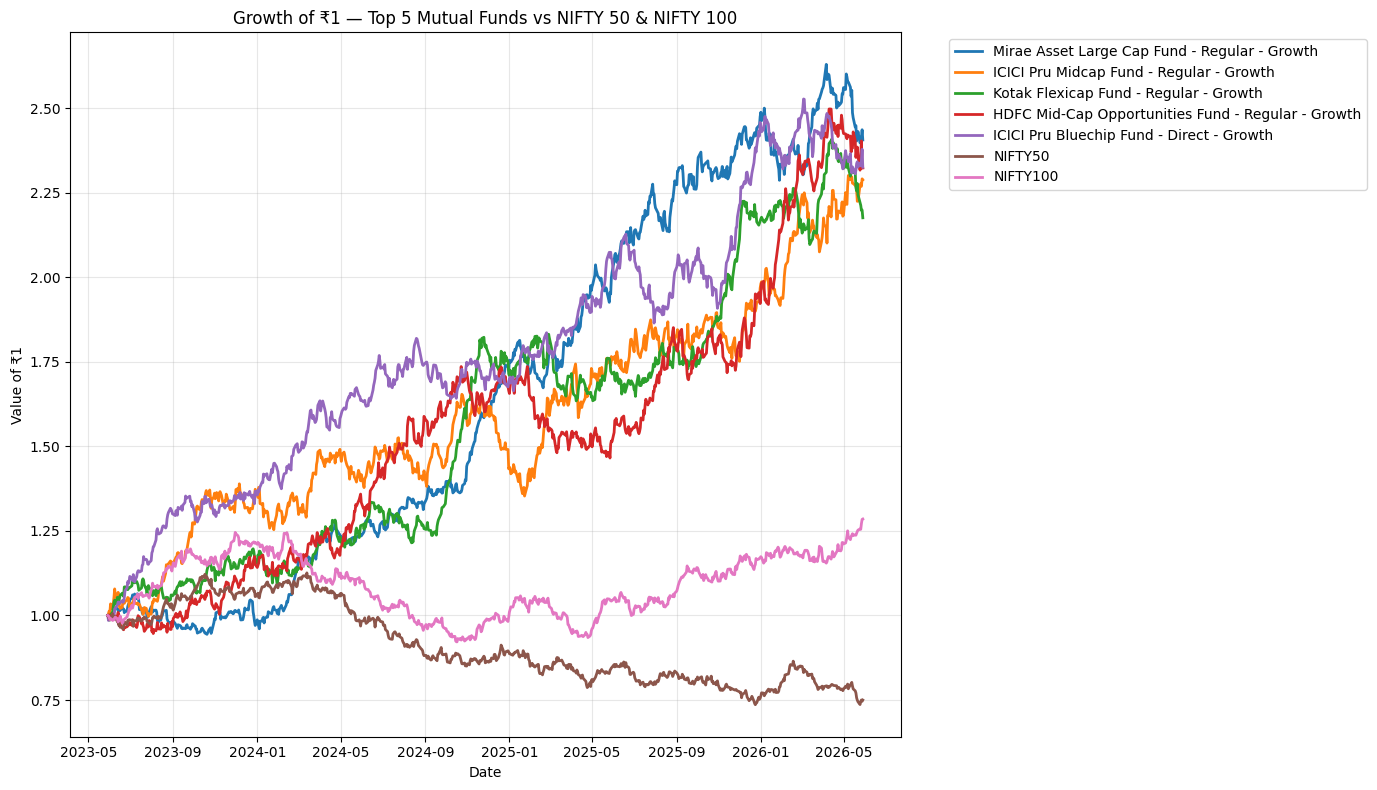

In [25]:
# ============================================================
# BENCHMARK COMPARISON CHART
# ============================================================

plt.figure(figsize=(14, 8))

for series in growth_df["series_name"].unique():

    series_data = growth_df[
        growth_df["series_name"] == series
    ].sort_values("date")

    plt.plot(
        series_data["date"],
        series_data["growth_of_1"],
        label=series,
        linewidth=2
    )

plt.title(
    "Growth of ₹1 — Top 5 Mutual Funds vs NIFTY 50 & NIFTY 100"
)

plt.xlabel("Date")
plt.ylabel("Value of ₹1")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../benchmark_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
# ============================================================
# TRACKING ERROR — TOP 5 FUNDS VS NIFTY 50 & NIFTY 100
# ============================================================

print("=" * 70)
print("TRACKING ERROR CALCULATION")
print("=" * 70)

tracking_error_results = []

for _, fund in top_5_funds.iterrows():

    amfi_code = fund["amfi_code"]
    scheme_name = fund["scheme_name"]

    # Get fund daily returns
    fund_returns = nav[
        nav["amfi_code"] == amfi_code
    ][
        ["date", "daily_return"]
    ].copy()

    fund_returns = fund_returns[
        (fund_returns["date"] >= benchmark_start_date) &
        (fund_returns["date"] <= benchmark_end_date)
    ]

    # Compare against both benchmarks
    for benchmark_name in ["NIFTY50", "NIFTY100"]:

        benchmark_returns = benchmark_3y[
            benchmark_3y["index_name"].str.upper()
            == benchmark_name
        ][
            ["date", "benchmark_return"]
        ].copy()

        # Align fund and benchmark dates
        aligned = pd.merge(
            fund_returns,
            benchmark_returns,
            on="date",
            how="inner"
        ).dropna(
            subset=["daily_return", "benchmark_return"]
        )

        # Calculate active return
        active_return = (
            aligned["daily_return"]
            - aligned["benchmark_return"]
        )

        # Annualized tracking error
        tracking_error = (
            active_return.std()
            * np.sqrt(252)
        )

        tracking_error_results.append({
            "amfi_code": amfi_code,
            "scheme_name": scheme_name,
            "benchmark": benchmark_name,
            "tracking_error": tracking_error,
            "observations": len(aligned)
        })


tracking_error_table = pd.DataFrame(
    tracking_error_results
)

print("\nTracking Error Results:")

display(
    tracking_error_table.sort_values(
        ["benchmark", "tracking_error"]
    )
)

print("\nTracking Error Summary:")
display(
    tracking_error_table[
        ["benchmark", "tracking_error"]
    ].groupby("benchmark")
    .describe()
)

TRACKING ERROR CALCULATION

Tracking Error Results:


,amfi_code,scheme_name,benchmark,tracking_error,observations
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY100,0.187299,784
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,0.187974,784
5,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY100,0.206540,784
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,0.224976,784
3,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,0.232661,784
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY50,0.188211,784
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,0.191868,784
4,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY50,0.205067,784
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,0.228222,784
2,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,0.228447,784



Tracking Error Summary:


tracking_error                                                    \
                   count      mean       std       min       25%       50%   
benchmark                                                                    
NIFTY100             5.0  0.207890  0.020785  0.187299  0.187974  0.206540   
NIFTY50              5.0  0.208363  0.019279  0.188211  0.191868  0.205067   

                               
                75%       max  
benchmark                      
NIFTY100   0.224976  0.232661  
NIFTY50    0.228222  0.228447

In [27]:
scorecard.to_csv(
    "../fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


In [28]:

alpha_beta_table.to_csv(
    "../alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [29]:

import os

project_root = ".."

required_files = [
    "fund_scorecard.csv",
    "alpha_beta.csv",
    "benchmark_comparison_chart.png",
    "notebooks/Performance_Analytics.ipynb"
]

print("=" * 70)
print("FINAL DELIVERABLE CHECK")
print("=" * 70)

for file in required_files:
    path = os.path.join(project_root, file)

    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"✅ {file} — {size_kb:.2f} KB")
    else:
        print(f"❌ {file} — NOT FOUND")

FINAL DELIVERABLE CHECK
✅ fund_scorecard.csv — 11.44 KB
✅ alpha_beta.csv — 2.81 KB
✅ benchmark_comparison_chart.png — 690.65 KB
✅ notebooks/Performance_Analytics.ipynb — 474.95 KB
